# Customer Churn Prediction
## Telco Customer Churn Dataset

**Author:** Akil Ahnaf   
**Date:** April 2026  
**Tools:** Python 3.11, Pandas, Scikit-learn, Matplotlib, Seaborn

---

### Project Overview
In this project I built a machine learning model to predict customer churn 
for a telecommunications company using the Telco Customer Churn dataset. 
Churn prediction is one of the most valuable and widely used applications 
of machine learning in business — identifying at-risk customers before they 
leave allows companies to intervene with targeted retention strategies.

### Key Findings
- Logistic Regression outperformed Random Forest (ROC-AUC: 0.84 vs 0.82)
- Contract type and tenure are the strongest predictors of customer loyalty
- Fiber optic internet customers churn at significantly higher rates
- Electronic check payment method is strongly associated with churn

## 1. Setup & Imports
Loading all required libraries for data manipulation, visualization, and modeling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, RocCurveDisplay

# Reusable evaluation function
def evaluate_model(name, y_test, preds, model, X_test):
    print(f"{'='*50}")
    print(f" {name}")
    print(f"{'='*50}")
    
    cm = confusion_matrix(y_test, preds)
    print("\nConfusion Matrix:")
    print(f"                 Predicted No  Predicted Yes")
    print(f"Actual No        {cm[0][0]}          {cm[0][1]}")
    print(f"Actual Yes       {cm[1][0]}          {cm[1][1]}")
    
    print("\nClassification Report:")
    print(classification_report(y_test, preds, target_names=['No Churn', 'Churn']))
    
    probs = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, probs)
    print(f"ROC-AUC Score: {auc:.3f}")

## 2. Load & Inspect Data
Loading the Telco Customer Churn dataset and performing an initial inspection 
of its structure, dimensions, and data types.

In [3]:
# Load the dataset
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# First look at the data
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Check column names, data types, and missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
# Check basic statistics for numeric columns
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## 3. Exploratory Data Analysis (EDA)
Visualizing distributions and relationships between features and churn to 
build intuition before modeling. Key questions: Which features correlate 
with churn? Is the dataset imbalanced?

In [6]:
# Check the churn distribution - how many customers actually churned?
print(df['Churn'].value_counts())
print()
print(df['Churn'].value_counts(normalize=True) * 100)

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


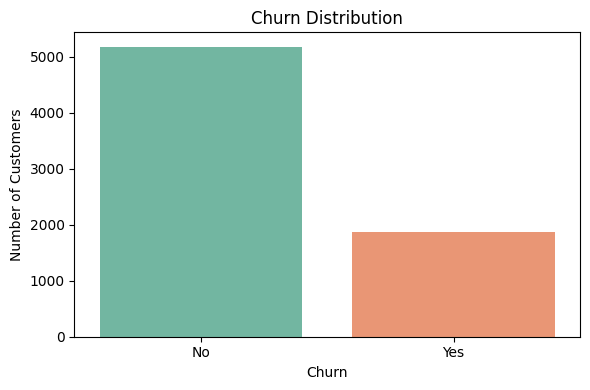

In [7]:
# Visualize the churn distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df, hue='Churn', palette='Set2', legend=False)
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

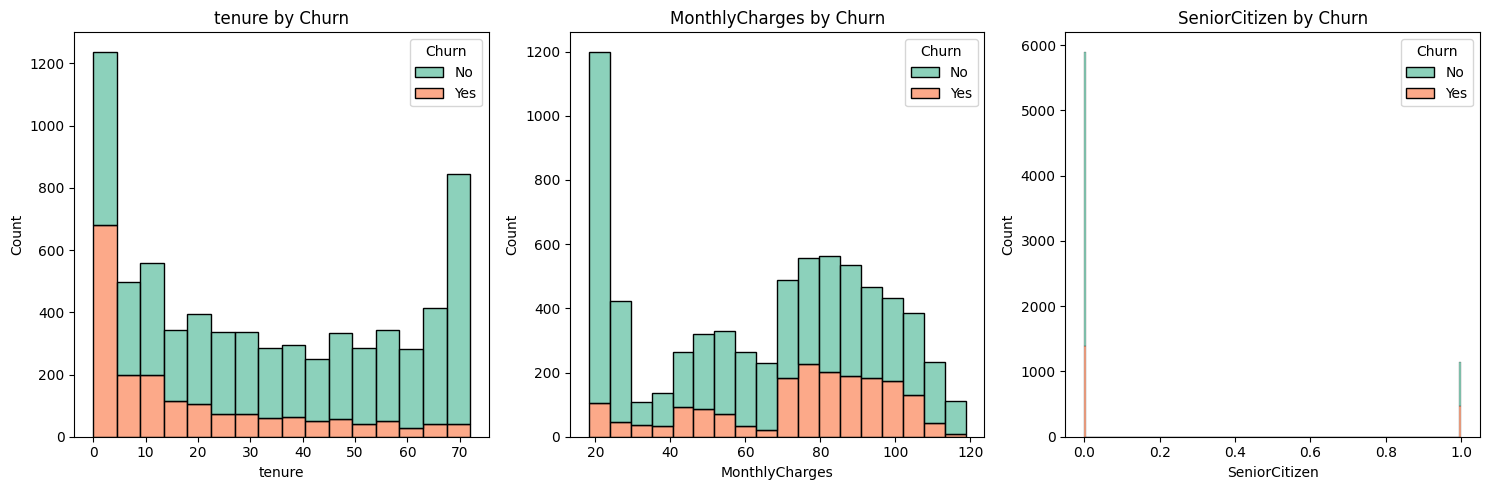

In [8]:
# Compare numeric features between churned and non-churned customers
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

numeric_cols = ['tenure', 'MonthlyCharges', 'SeniorCitizen']

for i, col in enumerate(numeric_cols):
    sns.histplot(data=df, x=col, hue='Churn', multiple='stack', ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col} by Churn')
    axes[i].set_xlabel(col)

plt.tight_layout()
plt.show()

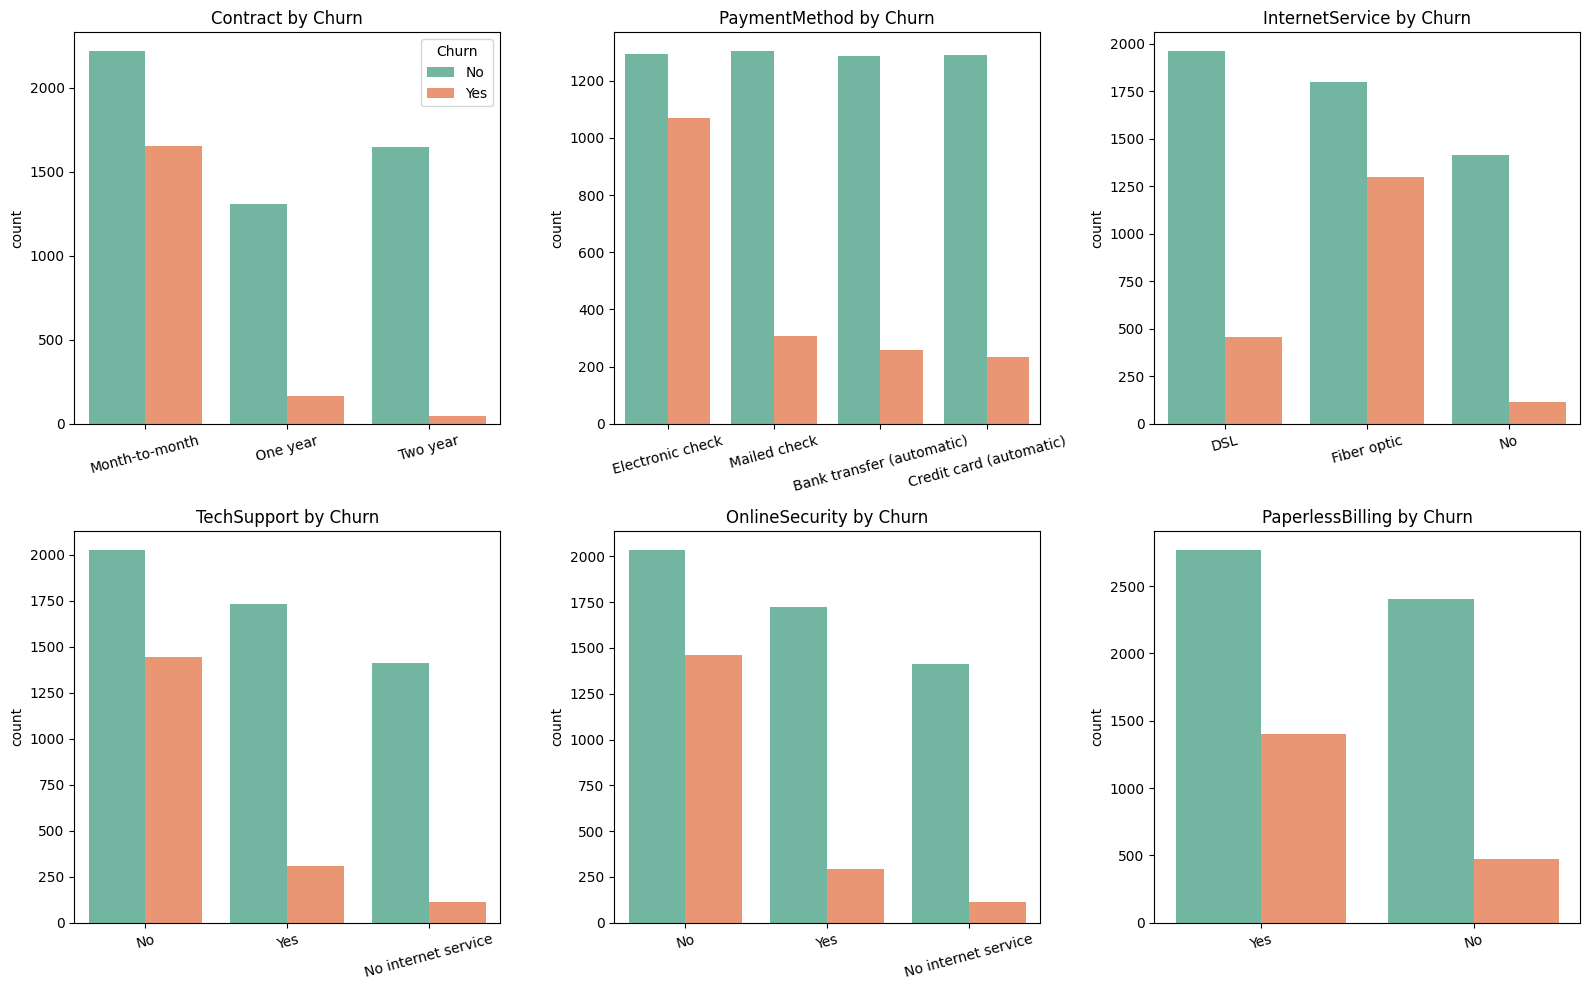

In [9]:
# Look at churn rate across key categorical features
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

categorical_cols = ['Contract', 'PaymentMethod', 'InternetService', 
                    'TechSupport', 'OnlineSecurity', 'PaperlessBilling']

for i, col in enumerate(categorical_cols):
    ax = axes[i//3, i%3]
    sns.countplot(x=col, data=df, hue='Churn', palette='Set2', ax=ax, legend=(i==0))
    ax.set_title(f'{col} by Churn')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

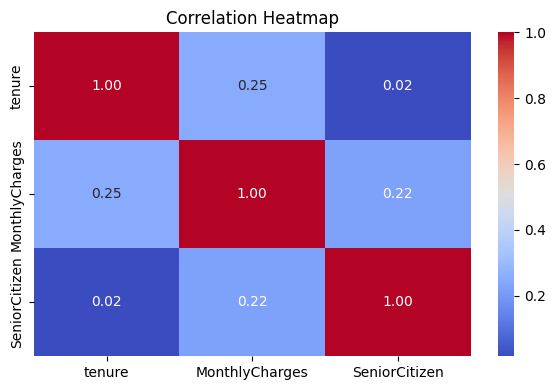

In [10]:
# Correlation heatmap of numeric features
plt.figure(figsize=(6, 4))
numeric_df = df[['tenure', 'MonthlyCharges', 'SeniorCitizen']].copy()
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

## 4. Data Cleaning & Preprocessing
Fixing data quality issues identified during EDA: converting TotalCharges 
to numeric, handling missing values, encoding categorical variables, 
and scaling numeric features.

In [11]:
# TotalCharges has spaces " " disguised as missing values
# Replace spaces with NaN so pandas recognizes them as missing
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)

# Now convert TotalCharges from string to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

# Check how many missing values we now have
print(df.isnull().sum())

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [12]:
# Drop the 11 rows with missing TotalCharges
df = df.dropna(subset=['TotalCharges'])

# Drop customerID - it's just a unique identifier, not a useful pattern for the model
df = df.drop(columns=['customerID'])

# Confirm the fix
print(df.shape)
print(df.isnull().sum().sum(), "missing values remaining")

(7032, 20)
0 missing values remaining


In [13]:
# Convert Churn from Yes/No to 1/0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Confirm it worked
print(df['Churn'].value_counts())
print(df['Churn'].dtype)

Churn
0    5163
1    1869
Name: count, dtype: int64
int64


In [14]:
# Get list of categorical columns to encode
cat_cols = df.select_dtypes(include='str').columns.tolist()
print("Categorical columns to encode:", cat_cols)

# Apply one-hot encoding
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Confirm the result
print(df.shape)
print(df.dtypes)

Categorical columns to encode: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
(7032, 31)
SeniorCitizen                              int64
tenure                                     int64
MonthlyCharges                           float64
TotalCharges                             float64
Churn                                      int64
gender_Male                                 bool
Partner_Yes                                 bool
Dependents_Yes                              bool
PhoneService_Yes                            bool
MultipleLines_No phone service              bool
MultipleLines_Yes                           bool
InternetService_Fiber optic                 bool
InternetService_No                          bool
OnlineSecurity_No internet service          bool
OnlineSecurity_Yes              

In [15]:
# Convert all bool columns to integers (True=1, False=0)
df = df.astype({col: int for col in df.select_dtypes(include='bool').columns})

# Final check - confirm everything is numeric
print(df.dtypes.value_counts())
print()
print(df.shape)

int64      29
float64     2
Name: count, dtype: int64

(7032, 31)


## 5. Feature Engineering & Selection
Separating features (X) from the target variable (y). Scaling will be 
applied after the train/test split to prevent data leakage.

In [16]:
# Separate features (X) and target (y)
X = df.drop(columns=['Churn'])
y = df['Churn']

# Confirm the shapes
print("X shape:", X.shape)
print("y shape:", y.shape)
print()
print("Features we're using:")
print(X.columns.tolist())

X shape: (7032, 30)
y shape: (7032,)

Features we're using:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


## 6. Train/Test Split & Feature Scaling
Splitting data 80/20 with stratification to preserve the churn ratio.
Scaler is fit ONLY on training data, then applied to test data separately.
This prevents data leakage — the model never indirectly sees test data during training.

In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Columns that need scaling
scale_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# STEP 1: Split FIRST before any scaling
# This ensures the scaler never sees test data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# STEP 2: Fit scaler ONLY on training data
# fit_transform on train = learns mean/std from training data only
# transform on test = applies those same statistics without learning from test
scaler = StandardScaler()
X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols] = scaler.transform(X_test[scale_cols])

# Confirm splits
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print()
print("Training churn rate:", y_train.mean().round(3))
print("Testing churn rate:", y_test.mean().round(3))
print()
print("Scaling preview (train):")
print(X_train[scale_cols].describe().round(2))

X_train shape: (5625, 30)
X_test shape: (1407, 30)

Training churn rate: 0.266
Testing churn rate: 0.266

Scaling preview (train):
        tenure  MonthlyCharges  TotalCharges
count  5625.00         5625.00       5625.00
mean     -0.00            0.00          0.00
std       1.00            1.00          1.00
min      -1.29           -1.55         -1.00
25%      -0.96           -0.97         -0.83
50%      -0.15            0.19         -0.39
75%       0.96            0.83          0.66
max       1.61            1.78          2.81


## 7. Model Training
Training two classification models for comparison:
- Logistic Regression: simple, interpretable baseline
- Random Forest: ensemble method using 100 decision trees

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Initialize Logistic Regression
# class_weight='balanced' tells the model to pay more attention to churners
# since they are the minority class (27% of data)
lr_model = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')

# Train it on the training data
lr_model.fit(X_train, y_train)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [19]:
# Initialize Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train it on the training data
rf_model.fit(X_train, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


## 7b. Cross-Validation
Validating model stability using 5-fold cross-validation.
A single train/test split can get lucky — cross-validation runs the
evaluation 5 times on different data splits and averages the results,
giving a more reliable estimate of real-world performance.

In [20]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Use stratified k-fold to preserve churn ratio in each fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Cross-validate both models using ROC-AUC
lr_cv_scores = cross_val_score(lr_model, X_train, y_train, cv=cv, scoring='roc_auc')
rf_cv_scores = cross_val_score(rf_model, X_train, y_train, cv=cv, scoring='roc_auc')

print("Logistic Regression — 5-Fold Cross-Validation ROC-AUC:")
print(f"  Scores: {lr_cv_scores.round(3)}")
print(f"  Mean:   {lr_cv_scores.mean():.3f}")
print(f"  Std:    {lr_cv_scores.std():.3f}")
print()
print("Random Forest — 5-Fold Cross-Validation ROC-AUC:")
print(f"  Scores: {rf_cv_scores.round(3)}")
print(f"  Mean:   {rf_cv_scores.mean():.3f}")
print(f"  Std:    {rf_cv_scores.std():.3f}")

Logistic Regression — 5-Fold Cross-Validation ROC-AUC:
  Scores: [0.847 0.843 0.837 0.849 0.853]
  Mean:   0.846
  Std:    0.005

Random Forest — 5-Fold Cross-Validation ROC-AUC:
  Scores: [0.828 0.814 0.822 0.832 0.84 ]
  Mean:   0.827
  Std:    0.009


## 7c. Hyperparameter Tuning with GridSearchCV
Using GridSearchCV to find the optimal hyperparameters for Logistic Regression.
Rather than guessing parameter values, GridSearchCV systematically tries every
combination and uses cross-validation to find which performs best.

In [21]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
# C = regularization strength (smaller = more regularization)
# solver = optimization algorithm
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'liblinear'],
    'max_iter': [1000]
}

# Initialize base model
lr_base = LogisticRegression(random_state=42, class_weight='balanced')

# GridSearchCV tries every combination using 5-fold cross-validation
grid_search = GridSearchCV(
    lr_base,
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

# Fit on training data only
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Val ROC-AUC:", round(grid_search.best_score_, 3))

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters: {'C': 100, 'max_iter': 1000, 'solver': 'liblinear'}
Best Cross-Val ROC-AUC: 0.846


In [22]:
# Retrain using the best parameters found by GridSearchCV
best_lr_model = grid_search.best_estimator_

# Evaluate on test set
best_lr_preds = best_lr_model.predict(X_test)

print("Tuned Logistic Regression — Test Set Performance:")
print()
evaluate_model("Tuned Logistic Regression", y_test, best_lr_preds, best_lr_model, X_test)

Tuned Logistic Regression — Test Set Performance:

 Tuned Logistic Regression

Confusion Matrix:
                 Predicted No  Predicted Yes
Actual No        722          311
Actual Yes       75          299

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.91      0.70      0.79      1033
       Churn       0.49      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.73      0.74      1407

ROC-AUC Score: 0.834


## 7d. Pipeline Implementation
Wrapping the best model in a sklearn Pipeline — the industry standard approach.
A Pipeline chains preprocessing and modeling into a single object, eliminating
the risk of data leakage and making the model easy to deploy and reuse.

In [23]:
from sklearn.pipeline import Pipeline

# Build pipeline with scaling + best logistic regression parameters
churn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        C=100,
        solver='liblinear',
        max_iter=1000,
        random_state=42,
        class_weight='balanced'
    ))
])

# Fit pipeline on RAW (unscaled) training data
# The pipeline handles scaling internally - no leakage possible
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

churn_pipeline.fit(X_train_raw, y_train_raw)

# Evaluate pipeline
pipeline_preds = churn_pipeline.predict(X_test_raw)
print("Pipeline — Test Set Performance:")
print()
evaluate_model("Pipeline (Tuned LR)", y_test_raw, pipeline_preds, churn_pipeline, X_test_raw)

print()
print("Pipeline cross-validation ROC-AUC:")
pipeline_cv = cross_val_score(churn_pipeline, X_train_raw, y_train_raw, cv=5, scoring='roc_auc')
print(f"  Scores: {pipeline_cv.round(3)}")
print(f"  Mean:   {pipeline_cv.mean():.3f}")
print(f"  Std:    {pipeline_cv.std():.3f}")

Pipeline — Test Set Performance:

 Pipeline (Tuned LR)

Confusion Matrix:
                 Predicted No  Predicted Yes
Actual No        722          311
Actual Yes       76          298

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.90      0.70      0.79      1033
       Churn       0.49      0.80      0.61       374

    accuracy                           0.72      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.72      0.74      1407

ROC-AUC Score: 0.834

Pipeline cross-validation ROC-AUC:
  Scores: [0.837 0.875 0.84  0.818 0.859]
  Mean:   0.846
  Std:    0.019


## 8. Model Evaluation
Evaluating both models using confusion matrix, precision, recall, F1-score, 
and ROC-AUC. Accuracy alone is misleading due to class imbalance (73/27 split).

In [24]:
# Make predictions on the TEST set
lr_preds = lr_model.predict(X_test)
rf_preds = rf_model.predict(X_test)

In [25]:
# Evaluate both models
evaluate_model("Logistic Regression", y_test, lr_preds, lr_model, X_test)
print()
evaluate_model("Random Forest", y_test, rf_preds, rf_model, X_test)

 Logistic Regression

Confusion Matrix:
                 Predicted No  Predicted Yes
Actual No        724          309
Actual Yes       77          297

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.90      0.70      0.79      1033
       Churn       0.49      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407

ROC-AUC Score: 0.835

 Random Forest

Confusion Matrix:
                 Predicted No  Predicted Yes
Actual No        917          116
Actual Yes       182          192

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.83      0.89      0.86      1033
       Churn       0.62      0.51      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.7

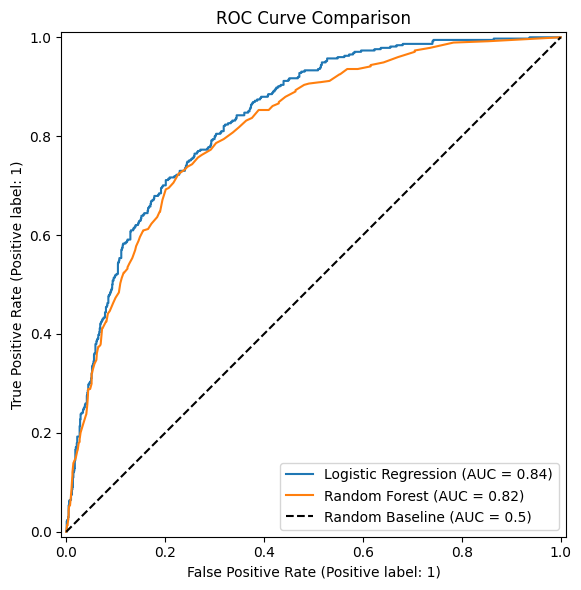

In [26]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

# Plot ROC curves for both models
fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_estimator(lr_model, X_test, y_test, ax=ax, name='Logistic Regression')
RocCurveDisplay.from_estimator(rf_model, X_test, y_test, ax=ax, name='Random Forest')

# Plot the random baseline (diagonal line)
ax.plot([0, 1], [0, 1], 'k--', label='Random Baseline (AUC = 0.5)')
ax.set_title('ROC Curve Comparison')
ax.legend()
plt.tight_layout()
plt.show()

## 9. Model Interpretation
Extracting logistic regression coefficients to understand which features 
drive churn. Positive coefficients increase churn probability, 
negative coefficients decrease it.

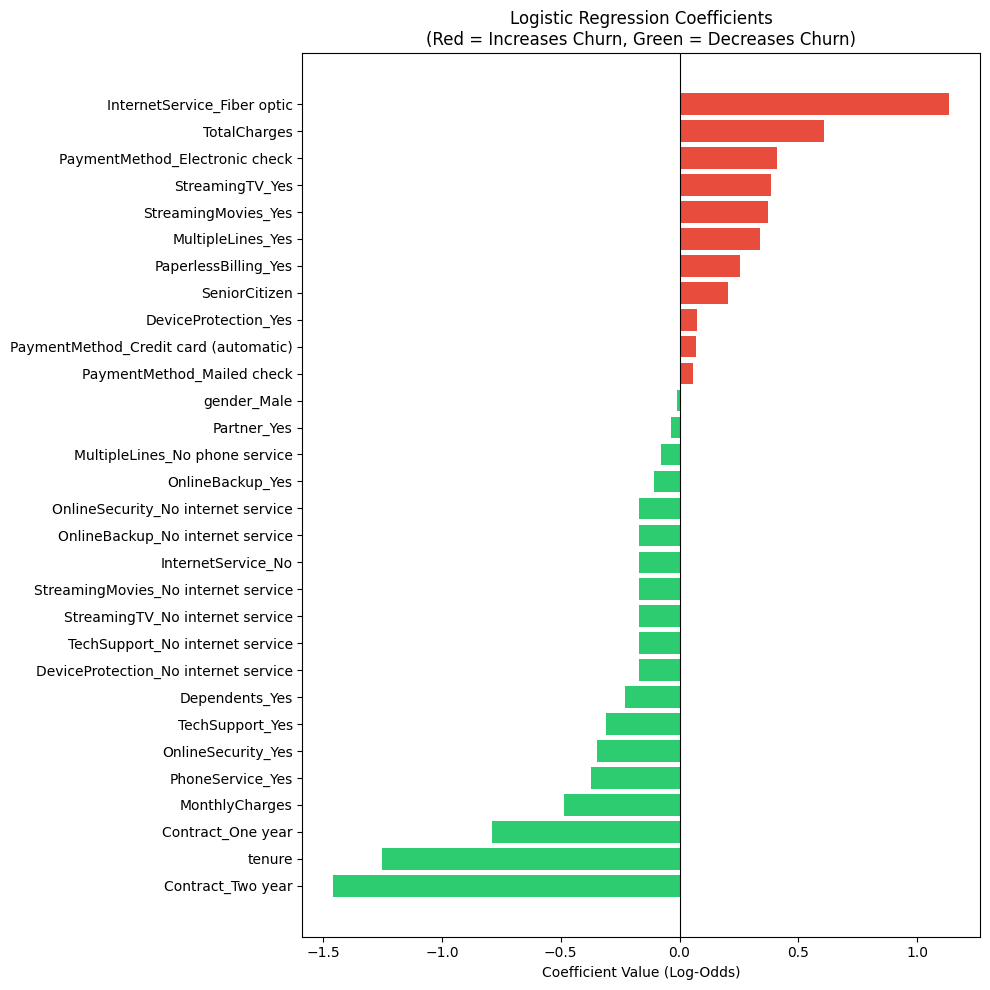

In [27]:
# Extract logistic regression coefficients
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_[0]
})

# Sort by coefficient value for plotting
coefficients = coefficients.sort_values('Coefficient')

# Plot
plt.figure(figsize=(10, 10))
colors = ['#e74c3c' if c > 0 else '#2ecc71' for c in coefficients['Coefficient']]
plt.barh(coefficients['Feature'], coefficients['Coefficient'], color=colors)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Logistic Regression Coefficients\n(Red = Increases Churn, Green = Decreases Churn)')
plt.xlabel('Coefficient Value (Log-Odds)')
plt.tight_layout()
plt.show()

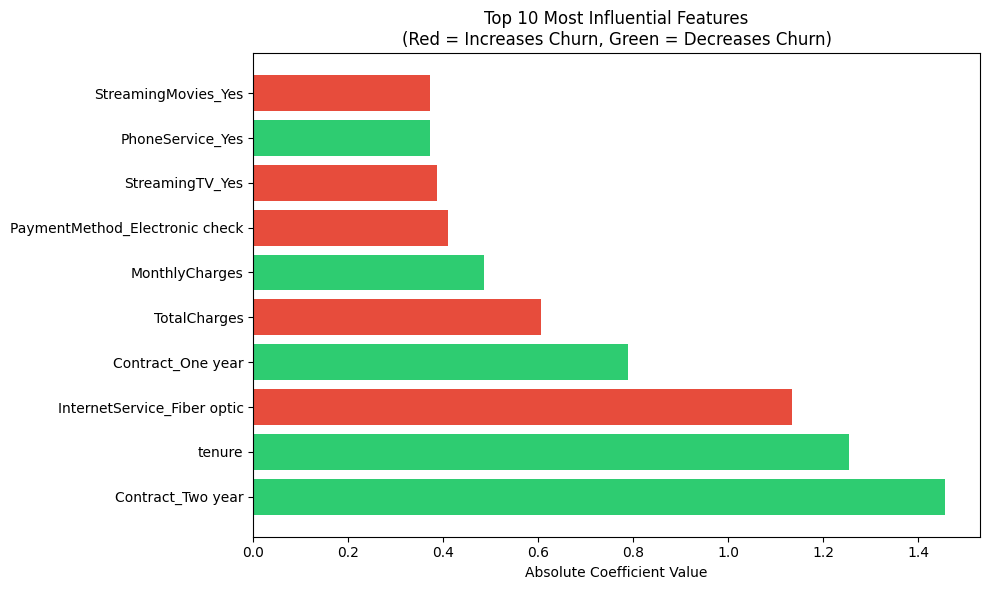

In [28]:
# Get top 10 features by absolute coefficient value
top10 = coefficients.reindex(
    coefficients['Coefficient'].abs().sort_values(ascending=False).index
).head(10)

# Plot
plt.figure(figsize=(10, 6))
colors = ['#e74c3c' if c > 0 else '#2ecc71' for c in top10['Coefficient']]
plt.barh(top10['Feature'], top10['Coefficient'].abs(), color=colors)
plt.title('Top 10 Most Influential Features\n(Red = Increases Churn, Green = Decreases Churn)')
plt.xlabel('Absolute Coefficient Value')
plt.tight_layout()
plt.show()

## 9b. Random Forest Feature Importance
Comparing which features Random Forest found most predictive.
Unlike logistic regression coefficients, these importance scores show
how much each feature reduced prediction error across all 100 trees,
but do not indicate direction (increase or decrease churn).

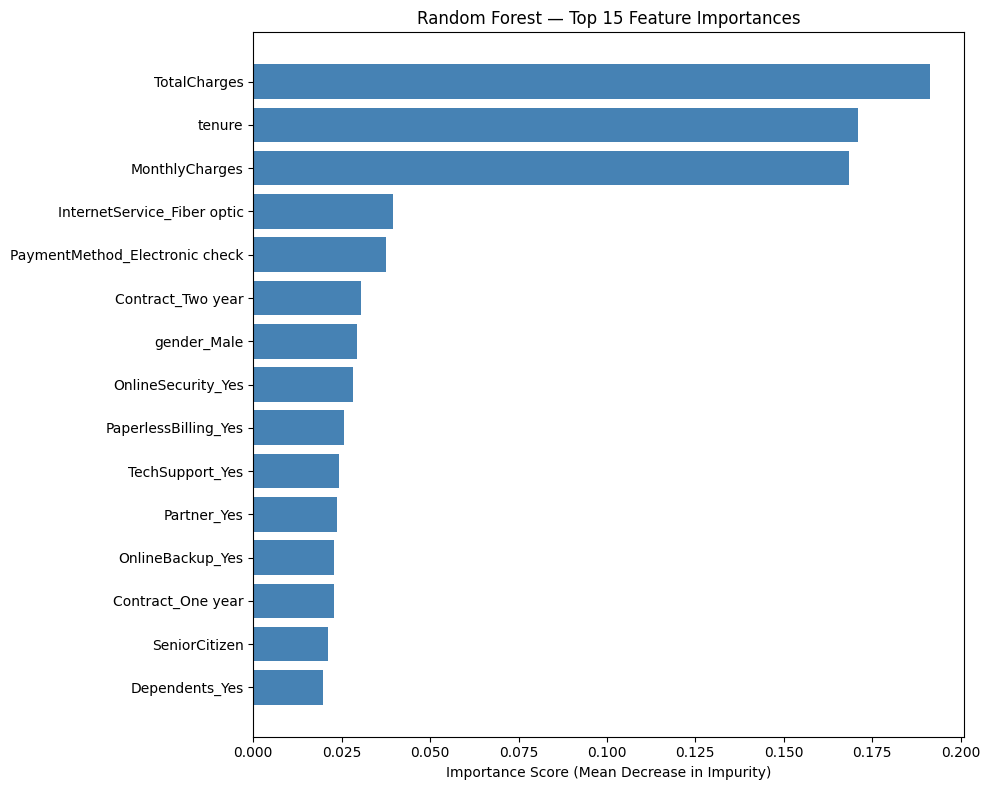

Top 10 Most Important Features (Random Forest):
                       Feature  Importance
                  TotalCharges    0.191435
                        tenure    0.171020
                MonthlyCharges    0.168400
   InternetService_Fiber optic    0.039481
PaymentMethod_Electronic check    0.037416
             Contract_Two year    0.030529
                   gender_Male    0.029332
            OnlineSecurity_Yes    0.028157
          PaperlessBilling_Yes    0.025536
               TechSupport_Yes    0.024114


In [29]:
# Random Forest Feature Importance
rf_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
})

# Sort by importance
rf_importance = rf_importance.sort_values('Importance', ascending=True)

# Plot top 15 most important features
top15_rf = rf_importance.tail(15)

plt.figure(figsize=(10, 8))
plt.barh(top15_rf['Feature'], top15_rf['Importance'], color='steelblue')
plt.title('Random Forest — Top 15 Feature Importances')
plt.xlabel('Importance Score (Mean Decrease in Impurity)')
plt.tight_layout()
plt.show()

# Print top 10 as a table
print("Top 10 Most Important Features (Random Forest):")
print(rf_importance.tail(10).sort_values('Importance', ascending=False).to_string(index=False))

## 11. Save the Model
Saving the final trained pipeline to disk using joblib.
This allows the model to be loaded and used for predictions
without retraining — a key step toward real deployment.

In [30]:
import joblib

# Save the trained pipeline to disk
joblib.dump(churn_pipeline, 'churn_model.pkl')
print("Model saved successfully as 'churn_model.pkl'")

# Verify it loads back correctly
loaded_model = joblib.load('churn_model.pkl')
test_pred = loaded_model.predict(X_test_raw[:5])
print("Model loaded and verified — sample predictions:", test_pred)

Model saved successfully as 'churn_model.pkl'
Model loaded and verified — sample predictions: [0 1 0 0 0]


## 10. Conclusions & Business Recommendations

### Model Development Journey
This project progressed through three stages of model refinement:
1. **Baseline** — Logistic Regression with default parameters
2. **Tuned** — GridSearchCV found optimal C=100, solver=liblinear
3. **Pipeline** — Industry-standard implementation eliminating leakage risk

### Final Model Performance (Pipeline — Tuned Logistic Regression)
- **ROC-AUC: 0.834** — strong ability to distinguish churners from non-churners
- **Recall: 80%** — catches 4 out of 5 actual churners
- **Precision: 49%** — deliberate tradeoff to maximize churn detection
- **CV Mean AUC: 0.846 ± 0.019** — stable and reliable across 5 folds

### Why Logistic Regression beat Random Forest
| Metric | Logistic Regression | Random Forest |
|--------|-------------------|---------------|
| ROC-AUC | 0.834 | 0.816 |
| Churn Recall | 80% | 51% |
| CV Mean AUC | 0.846 | 0.827 |

Simpler models often outperform complex ones on clean, moderately sized
datasets. Logistic Regression is also more interpretable — we can explain
exactly why each prediction was made, which matters in business settings.

### How a Company Would Use This Model
In practice, this pipeline would run monthly on the full customer database.
Each customer receives a churn probability score between 0 and 1. Customers
above a set threshold (e.g. 0.5) get flagged for intervention — a retention
offer, a proactive support call, or a contract upgrade incentive. The model
essentially turns a reactive problem ("why did they leave?") into a proactive
one ("who is about to leave?").

### Key Insights
| Driver | Effect |
|--------|--------|
| Two year contract | Strongest loyalty factor |
| Long tenure | Customers stay once embedded |
| Fiber optic internet | Biggest churn risk |
| Electronic check payment | High churn association |
| Online security & tech support | Reduce churn when present |

### Business Recommendations
1. **Incentivize longer contracts** — offer discounts for one or two year
commitments, especially for new customers
2. **Investigate fiber optic satisfaction** — conduct surveys with fiber
optic customers to understand dissatisfaction drivers
3. **Target electronic check users** — proactively reach out to this segment
with retention offers
4. **Bundle protective services** — promote tech support and online security
add-ons as they correlate with lower churn

### What I'd Improve With More Time
- **SMOTE oversampling** — handle class imbalance at the data level rather
than through class weights alone
- **XGBoost / LightGBM** — test gradient boosting models which often
outperform logistic regression on larger datasets
- **SHAP values** — go beyond coefficients for deeper, more nuanced model
explainability
- **Threshold tuning** — systematically find the optimal decision threshold
rather than using the default 0.5
- **Streamlit deployment** — wrap the pipeline in a simple web app so
non-technical stakeholders can get predictions without touching code